# TP : Construction d'un U-Net Personnalisé pour la Segmentation Sémantique

Ce TP vous guide dans la construction complète d'un réseau U-Net pour la segmentation sémantique. Le U-Net est une architecture encodeur-décodeur avec des connexions skip (connexions résiduelles) qui permettent de préserver les détails spatiaux tout en capturant des informations sémantiques de haut niveau.

Vous allez implémenter cette architecture en réutilisant un encodeur VGG16 pré-entraîné et en construisant un décodeur symétrique avec des convolutions transposées. L'objectif est de comprendre la structure du U-Net, de l'entraîner sur un dataset de scènes urbaines, et d'évaluer ses performances en segmentation sémantique pixel par pixel.

Ce TP couvre l'ensemble d'un pipeline simple : préparation des données avec transformations, construction modulaire de l'architecture, boucle d'entraînement avec validation, early stopping, sauvegarde/chargement de modèle et évaluation finale.

In [4]:
import os
import glob
import cv2
import numpy as np
import shutil
import matplotlib.pyplot as plt
import albumentations as A
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from tqdm.notebook import tqdm

### Détecter le device de calcul

Créez une variable `device` qui détecte automatiquement le matériel disponible pour l'entraînement : utilisez CUDA si disponible (GPU NVIDIA), sinon MPS pour les Mac avec puce Apple Silicon (M1/M2/M3), sinon le CPU. Affichez le device sélectionné pour confirmer la configuration matérielle.

In [5]:
# Détection du device (mps pour les Mac M1/M2)
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("Using device:", device)

Using device: cpu


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Définir le répertoire des données

Indiquez le chemin vers le répertoire contenant le dataset de segmentation (`../data/seg-dataset`).

In [6]:
data_dir = "/content/drive/MyDrive/computer_vision/td13/data/seg-dataset"

### Créer un ensemble de validation (si nécessaire)

Si votre dataset ne contient pas déjà un ensemble de validation, créez-en un à partir d'une partie de l'ensemble d'entraînement :
- Créer les dossiers `valid/images` et `valid/masks`
- Sélectionner aléatoirement 20% des fichiers d'entraînement
- Déplacer ces fichiers vers le dossier de validation

Laissez cette cellule commentée si votre dataset possède déjà un ensemble de validation séparé.

In [7]:
# TODO
os.makedirs(f"{data_dir}/valid",exist_ok=True)
os.makedirs(f"{data_dir}/valid/images",exist_ok=True)
os.makedirs(f"{data_dir}/valid/masks",exist_ok=True)
train_val_image_files = glob.glob(f"{data_dir}/train/images/*.png")
train_val_mask_files = glob.glob(f"{data_dir}/train/masks/*.png")
test_image_files = glob.glob(f"{data_dir}/test/images/*.png")
test_mask_files = glob.glob(f"{data_dir}/test/masks/*.png")
val_size=int(len(train_val_mask_files)*0.2)

np.random.seed(42)  # fixe la graine

val_index = np.random.choice(len(train_val_mask_files), size=val_size, replace=False)
val_index_sorted = np.sort(val_index)

val_index_sorted=np.array(np.sort(val_index))
val_image_files=np.array(train_val_image_files)[val_index_sorted]
val_mask_files=np.array(train_val_mask_files)[val_index_sorted]

train_image_files=np.array(train_val_image_files)[np.setdiff1d(np.arange(len(train_val_mask_files)), val_index_sorted)]
train_mask_files=np.array(train_val_mask_files)[np.setdiff1d(np.arange(len(train_val_mask_files)), val_index_sorted)]

print(f"Number of training images: {len(train_image_files)}")
print(f"Number of training masks: {len(train_mask_files)}")
print(f"Number of training images: {len(val_image_files)}")
print(f"Number of training masks: {len(val_mask_files)}")

Number of training images: 294
Number of training masks: 294
Number of training images: 73
Number of training masks: 73


In [53]:
# for img,mask in zip(val_image_files,val_mask_files):
#   shutil.copy(img,f"{data_dir}/valid/images")
#   shutil.copy(mask,f"{data_dir}/valid/masks")


### Créer la classe `SegDataset` pour Dataset personnalisée

Implémentez la classe `SegDataset` héritant de `torch.utils.data.Dataset` pour charger et préparer les données de segmentation. Cette classe doit inclure :

**Attributs de classe :**
- `IMAGE_SIZE` : tuple définissant la taille de redimensionnement des images (ici : (384, 384))
- `CLASS_MAPPING` : dictionnaire associant les ID de classes (0-11) à leurs noms sémantiques
- `MEAN` et `STD` : valeurs de normalisation ImageNet standard
- `IMAGE_TRANSFORM` : pipeline Albumentations pour les images (resize, normalize, toTensor)
- `MASK_TRANSFORM` : pipeline Albumentations pour les masques (resize, toTensor)

NB : pour mieux généraliser on pourrait ajouter des transformations, mais ceci est un exercice sur un dataset simple

**Méthodes de classe :**
- `unnormalize_image(tensor)` : convertit un tenseur normalisé en image numpy visualisable
- `show_image_and_mask(image, mask, figsize)` : affiche côte à côte une image et son masque

**Méthodes d'instance :**
- `__init__(self, split_dir, image_transform, mask_transform)` : initialise le dataset avec le répertoire du split (train/valid/test) et les transformations
- `__len__(self)` : retourne le nombre d'échantillons
- `__getitem__(self, idx)` : charge une paire image/masque, applique les transformations et retourne les tenseurs (note : convertir le masque en `long` pour la CrossEntropyLoss)

La classe doit charger les images en RGB avec OpenCV et lire les masques avec `IMREAD_UNCHANGED` pour préserver les valeurs de pixels exactes.

In [8]:
class SegDataset(Dataset):

    IMAGE_SIZE = (384, 384)

    CLASS_MAPPING = {
      0: "sky",
      1: "building",
      2: "pole",
      3: "road",
      4: "sidewalk",
      5: "vegetation",
      6: "sign",
      7: "fence",
      8: "vehicle",
      9: "person",
      10: "rider",
      11: "void"
  }

    MEAN = torch.tensor([0.485, 0.456, 0.406],dtype=torch.float)
    STD = torch.tensor([0.229, 0.224, 0.225],dtype=torch.float)
    # NB : pour mieux généraliser on pourrait ajouter des transformations,
    # mais ceci est un exercice sur un dataset simple
    IMAGE_TRANSFORM = A.Compose([
            # On ne fait pas de reca
            A.Resize(IMAGE_SIZE[0], IMAGE_SIZE[1]),
            A.Normalize(mean=MEAN, std=STD),
            A.ToTensorV2()
        ])

    MASK_TRANSFORM =  A.Compose([
            # On ne fait pas de reca
            A.Resize(IMAGE_SIZE[0], IMAGE_SIZE[1]),
            A.ToTensorV2()
        ])

    def unnormalize_image(tensor):
        """Convertit un tenseur d'image normalisé en une image numpy non normalisée."""
        image = tensor.numpy().transpose(1, 2, 0)
        image = (image * np.array(SegDataset.STD)) + np.array(SegDataset.MEAN)
        image = np.clip(image * 255, 0, 255).astype(np.uint8)
        return image

    def show_image_and_mask(image, mask, figsize=(10,5)):
        """Affiche une image et son masque de segmentation côte à côte, utilise cmap=tab20."""
        mask = mask.squeeze().numpy()
        plt.figure(figsize=figsize)
        plt.subplot(1, 2, 1)
        plt.imshow(SegDataset.unnormalize_image(image))
        plt.title("Image")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(mask, cmap='tab20', vmin=0, vmax=len(SegDataset.CLASS_MAPPING)-1)
        plt.title("Mask")
        plt.axis("off")

        plt.show()

    def __init__(self, split_dir, image_transform=IMAGE_TRANSFORM, mask_transform=MASK_TRANSFORM):
        """
        Dataset personnalisé pour la segmentation sémantique.

        Paramètres
        ----------
        split_dir : str
            Chemin vers le dossier du split (train | valid | test) contenant les sous-dossiers 'images' et 'masks'.
        image_transform : callable, optionnel
            Pipeline de transformations Albumentations à appliquer aux images (par défaut : IMAGE_TRANSFORM).
        mask_transform : callable, optionnel
            Pipeline de transformations Albumentations à appliquer aux masques (par défaut : MASK_TRANSFORM).
        """
        self.split_dir=split_dir
        self.image_tranform=image_transform
        self.mask_tranform=mask_transform

    def __len__(self):
        """Retourne le nombre d'échantillons dans le dataset."""
        return len(self.split_dir)

    def __getitem__(self, idx):
        """
        Charge une paire image/masque à l'index donné, applique les transformations et retourne les tenseurs.

        Paramètres
        ----------
        idx : int
            Index de l'échantillon à charger.

        Retourne
        --------
        image : torch.Tensor
            Image transformée (normalisée, tensorisée).
        mask : torch.Tensor
            Masque transformé (tensorisé, type `long`pour être compatible avec la fonction de perte CrossEntropy (CE) ).
        """

        row=self.split_dir[idx]
        image = cv2.cvtColor(cv2.imread(row[0]),cv2.COLOR_BGR2RGB)
        mask = cv2.imread(row[1], cv2.IMREAD_UNCHANGED)
        if self.image_tranform:
          image=self.image_tranform(image=image)['image']
        if self.mask_tranform:
          mask=self.mask_tranform(image=mask)['image']
        return image, mask.long().squeeze() # Convertit en long et squeeze pour supprimer la dimension canal pour la CrossEntropy Loss

### Instancier les datasets

Créez trois instances de `SegDataset` pour les ensembles d'entraînement, de validation et de test en utilisant les chemins appropriés (`train`, `valid`, `test`). Affichez le nombre d'échantillons dans chaque ensemble pour vérifier que les données sont correctement chargées.

In [9]:
train_dataset =SegDataset(np.array([ tuple((img,mask)) for img,mask in zip(train_image_files,train_mask_files)]))
valid_dataset = SegDataset(np.array([tuple((img,mask)) for img,mask in zip(val_image_files,val_mask_files)]))
test_dataset = SegDataset(np.array([tuple((img,mask))  for img, mask in zip(test_image_files,test_mask_files)]))
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(valid_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

Number of training samples: 294
Number of validation samples: 73
Number of test samples: 101


### Visualiser un exemple du dataset

Sélectionnez un échantillon du dataset de validation (par exemple `num = 40`) :
- chargez l'image et le masque correspondants,
- affichez leurs caractéristiques (forme et plage de valeurs),
- visualisez-les côte à côte avec la méthode `show_image_and_mask` de la classe `SegDataset`.

Image shape: torch.Size([3, 384, 384]), value range: [-1.9637811183929443, 2.6399998664855957]
Mask shape: torch.Size([384, 384]), value range: [0, 11]
Mask dtype: torch.int64


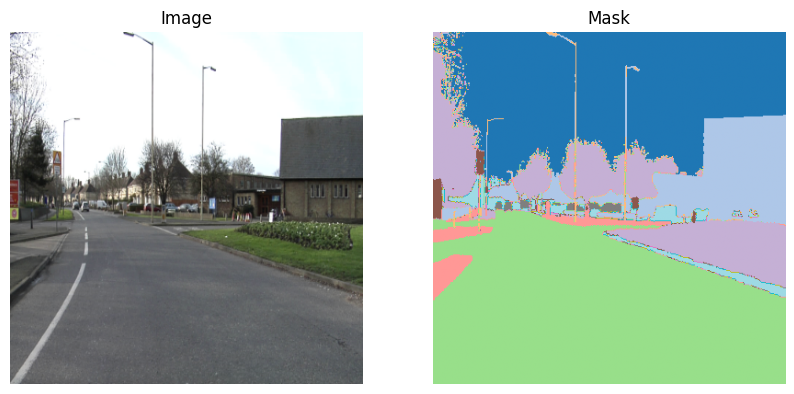

In [10]:
num = 40
image, mask =valid_dataset[num]
print(f"Image shape: {image.shape}, value range: [{image.min()}, {image.max()}]")
print(f"Mask shape: {mask.shape}, value range: [{mask.min()}, {mask.max()}]")
print(f"Mask dtype: {mask.dtype}")

SegDataset.show_image_and_mask(image,mask)

### Créer les DataLoaders

Créez trois `DataLoader` pour les ensembles d'entraînement, de validation et de test.

Adaptez la taille de batch en fonction du device (par exemple 8 pour CUDA, 4 pour CPU/MPS).

Activez le shuffle uniquement pour le train_loader.

Affichez le nombre de batchs dans chaque loader pour comprendre l'organisation des données.

In [11]:
batch_size = 32
train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
valid_loader = DataLoader(valid_dataset,batch_size=batch_size,shuffle=False)
test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False)
print(f"Batch size: {batch_size}")
print(f"Number of batches in train_loader: {len(train_loader)}")
print(f"Number of batches in valid_loader: {len(valid_loader)}")
print(f"Number of batches in test_loader: {len(test_loader)}")

Batch size: 32
Number of batches in train_loader: 10
Number of batches in valid_loader: 3
Number of batches in test_loader: 4


### Charger l'encodeur VGG16 pré-entraîné

Chargez les couches de features d'un VGG16 avec batch normalization, pré-entraîné sur ImageNet.

Utilisez `torchvision.models.vgg16_bn(weights='IMAGENET1K_V1').features` et affichez l'architecture complète de l'encodeur pour comprendre sa structure.

In [12]:
vgg16_encoder = torchvision.models.vgg16_bn(weights='IMAGENET1K_V1').features
display(vgg16_encoder)

Downloading: "https://download.pytorch.org/models/vgg16_bn-6c64b313.pth" to /root/.cache/torch/hub/checkpoints/vgg16_bn-6c64b313.pth


100%|██████████| 528M/528M [00:10<00:00, 55.0MB/s]


Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU(inplace=True)
  (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (9): ReLU(inplace=True)
  (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (12): ReLU(inplace=True)
  (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (14): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 

### Extraire les blocs de l'encodeur

Découpez l'encodeur VGG16 en 5 blocs distincts correspondant aux différentes résolutions spatiales.

Utilisez l'opérateur de décomposition `*` avec `nn.Sequential` pour créer chaque bloc à partir des tranches appropriées du `vgg16_encoder` :
- `block1`, `block2`, `block3`, `block4`, `block5`, `last_pool` (dernière MaxPool).

NB1 : Le découpage des blocs se fait avant les couches `MaxPool2d`, c'est-à-dire après les couches de convolution mais avant la réduction de dimension spatiale.

NB2 : cette architecture est totalement dépendante du modèle utilisé pour l'extraction de features (autre modèle = autre découpe)

In [13]:
# Le * (opérateur de décomposition) permet de "dépaqueter" une séquence (ici, une liste ou un slice de modules)
# Cela permet de créer un nn.Sequential contenant chaque module de encoder[:6] dans l'ordre.
block1 = nn.Sequential(*vgg16_encoder[:6])
display(block1)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU(inplace=True)
)

In [14]:
block2 = nn.Sequential(*vgg16_encoder[6:13])
display(block2)

Sequential(
  (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): ReLU(inplace=True)
  (4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU(inplace=True)
)

In [15]:
block3 = nn.Sequential(*vgg16_encoder[13:23])
display(block3)

Sequential(
  (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): ReLU(inplace=True)
  (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU(inplace=True)
  (7): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (9): ReLU(inplace=True)
)

In [16]:
block4 = nn.Sequential(*vgg16_encoder[23:33])
display(block4)

Sequential(
  (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (1): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): ReLU(inplace=True)
  (4): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU(inplace=True)
  (7): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (9): ReLU(inplace=True)
)

In [17]:
block5 = nn.Sequential(*vgg16_encoder[33:43])
display(block5)

Sequential(
  (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): ReLU(inplace=True)
  (4): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU(inplace=True)
  (7): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (9): ReLU(inplace=True)
)

In [18]:
last_pool = nn.Sequential(*vgg16_encoder[43:44])
display(last_pool)

Sequential(
  (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)

### Créer un bloc de convolution standard

Implémentez la classe `ConvBlock` héritant de `nn.Sequential` qui encapsule une séquence standard de couches pour le décodeur : convolution 2D, batch normalization et activation ReLU. Les paramètres du constructeur sont :
- `in_channels` : nombre de canaux d'entrée
- `out_channels` : nombre de canaux de sortie
- `kernel_size` : taille du noyau (défaut : 3)
- `stride` : pas de convolution (défaut : 1)
- `padding` : padding (défaut : 1)

Ce bloc sera utilisé pour les couches de convolution dans le décodeur.

In [19]:
class ConvBlock(nn.Sequential):
    """
    Bloc de convolution standard pour le décodeur U-Net.

    Ce bloc applique une séquence :
        - Convolution 2D (nn.Conv2d)
        - Normalisation par lot (nn.BatchNorm2d)
        - Activation ReLU (nn.ReLU)

    Paramètres
    ----------
    in_channels : int
        Nombre de canaux en entrée.
    out_channels : int
        Nombre de canaux en sortie.
    kernel_size : int, optionnel
        Taille du noyau de convolution (par défaut 3).
    stride : int, optionnel
        Pas de la convolution (par défaut 1).
    padding : int, optionnel
        Padding appliqué à l'entrée (par défaut 1).
    """
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )


### Créer un bloc de convolution transposée

Implémentez la classe `UpConvBlock` héritant de `nn.Sequential` qui effectue un upsampling (augmentation de résolution) via une convolution transposée suivie d'une activation ReLU. Les paramètres sont :
- `in_channels` : nombre de canaux d'entrée
- `out_channels` : nombre de canaux de sortie
- `kernel_size` : taille du noyau (défaut : 2)
- `stride` : pas de convolution transposée (défaut : 2, double la résolution spatiale)

Ce bloc sera utilisé dans le chemin ascendant du décodeur.

In [20]:
class UpConvBlock(nn.Sequential):
    """
    Bloc de convolution transposée pour l'upsampling dans le décodeur U-Net.

    Ce bloc applique une séquence :
        - Convolution transposée 2D (nn.ConvTranspose2d) pour doubler la résolution spatiale
        - Activation ReLU (nn.ReLU)

    Paramètres
    ----------
    in_channels : int
        Nombre de canaux en entrée.
    out_channels : int
        Nombre de canaux en sortie.
    kernel_size : int, optionnel
        Taille du noyau de la convolution transposée (par défaut 2).
    stride : int, optionnel
        Pas de la convolution transposée (par défaut 2, double la taille spatiale).
    """
    def __init__(self, in_channels, out_channels, kernel_size=2, stride=2):
        super().__init__(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride),
            nn.ReLU(inplace=True)
        )

### Tester le flux de données dans l'encodeur

Pour comprendre comment les dimensions évoluent dans l'encodeur, propagez l'image `num` du `valid_dataset` à travers tous les blocs.

Affichez la forme du tenseur après chaque bloc pour visualiser les réductions de résolution spatiale et l'augmentation du nombre de canaux.

In [21]:
with torch.no_grad():
    x = valid_dataset[num][0].unsqueeze(0)
    print("Input shape", x.shape)
    x = block1(x)
    print("After block1", x.shape)
    x = block2(x)
    print("After block2", x.shape)
    x = block3(x)
    print("After block3", x.shape)
    x = block4(x)
    print("After block4", x.shape)
    x = block5(x)
    print("After block5", x.shape)
    x = last_pool(x)
    print("After last_pool", x.shape)



Input shape torch.Size([1, 3, 384, 384])
After block1 torch.Size([1, 64, 384, 384])
After block2 torch.Size([1, 128, 192, 192])
After block3 torch.Size([1, 256, 96, 96])
After block4 torch.Size([1, 512, 48, 48])
After block5 torch.Size([1, 512, 24, 24])
After last_pool torch.Size([1, 512, 12, 12])


### Construire l'architecture U-Net complète

Implémentez la classe `MyUnet` héritant de `nn.Module` qui assemble un U-Net (basé ici sur `vgg16_bn`) complet avec :

**Dans le constructeur `__init__(self, num_classes)` :**
- Encodeur : les 5 blocs VGG16 (`enc_1` à `enc_5`)
- Bottleneck : MaxPool2d suivi de deux ConvBlock (512→1024→512)
- Décodeur : 4 niveaux d'upsampling avec skip connections
  - Chaque niveau contient un `UpConvBlock` pour l'upsampling et un `ConvBlock` pour traiter la concaténation (skip connection)
  - `up_1` et `dec_1` : remonte de 512 canaux, concatène avec `e_5`
  - `up_2` et `dec_2` : remonte à 256 canaux, concatène avec `e_4`
  - `up_3` et `dec_3` : remonte à 128 canaux, concatène avec `e_3`
  - `up_4` et `dec_4` : remonte à 64 canaux, concatène avec `e_2`
- Couche finale : `final_up` (UpConvBlock) puis `final_conv` (Conv2d 1×1) pour obtenir les logits de `num_classes` classes

**Dans la méthode `forward(self, x)` :**
- Propagez l'entrée à travers l'encodeur en conservant les sorties intermédiaires (`e_1` à `e_5`)
- Passez par le bottleneck
- Remontez le décodeur en concaténant (`torch.cat`) les features de l'encodeur avec celles du décodeur (dim=1)
- Retournez les logits de segmentation

Testez l'architecture en créant une instance du modèle, en le déplaçant sur le device, et en propageant un tenseur aléatoire de taille appropriée. Vérifiez que la forme de sortie correspond à `(batch_size, num_classes, height, width)`.

In [22]:
class MyUnet(nn.Module):
    """
    U-Net basé sur un encodeur VGG16-BN pré-entraîné pour la segmentation sémantique.

    Ce modèle assemble un U-Net utilisant les blocs de convolution extraits de VGG16-BN comme encodeur,
    un bottleneck, et un décodeur symétrique avec skip connections.

    Paramètres
    ----------
    num_classes : int
        Nombre de classes de segmentation (nombre de canaux de sortie).
    verbose : bool, optionnel
        Si True, affiche les formes des tenseurs à chaque étape du forward (par défaut False).

    Attributs
    ---------
    enc_1 à enc_5 : nn.Sequential
        Blocs d'encodeur issus de VGG16-BN.
    bottleneck : nn.Sequential
        Bloc central composé d'un MaxPool suivi de deux ConvBlock.
    up_1 à up_4 : UpConvBlock
        Blocs d'upsampling (convolutions transposées) du décodeur.
    dec_1 à dec_4 : ConvBlock
        Blocs de convolution du décodeur après concaténation avec les skip connections.
    final_up : UpConvBlock
        Dernier upsampling pour retrouver la résolution d'origine.
    final_conv : nn.Conv2d
        Convolution finale 1x1 pour produire les logits de segmentation.

    Méthodes
    --------
    forward(x)
        Propage l'entrée à travers l'encodeur, le bottleneck et le décodeur, puis retourne les logits.
    """
    def __init__(self, num_classes, verbose=False):
        super().__init__()
        self.verbose = verbose
        self.enc_1 = block1
        self.enc_2 = block2
        self.enc_3 = block3
        self.enc_4 = block4
        self.enc_5 = block5

        self.bottleneck = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),
            ConvBlock(512, 1024, 3, padding=1),
            ConvBlock(1024, 512, 3, padding=1)
        )

        self.up_1  = UpConvBlock(512, 512)
        self.dec_1 = ConvBlock(512 + 512, 512)

        self.up_2  = UpConvBlock(512, 256)
        self.dec_2 = ConvBlock(512 + 256, 256)

        self.up_3  = UpConvBlock(256, 128)
        self.dec_3 = ConvBlock(256 + 128, 128)

        self.up_4  = UpConvBlock(128, 64)
        self.dec_4 = ConvBlock(128 + 64, 64)

        self.final_up = UpConvBlock(64, 64)
        self.final_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        """
        Propage l'entrée à travers l'encodeur, le bottleneck et le décodeur U-Net.

        Si verbose est True, affiche les formes des tenseurs à chaque étape.

        Paramètres
        ----------
        x : torch.Tensor
            Tenseur d'entrée de forme (batch_size, 3, H, W).

        Retourne
        -------
        torch.Tensor
            Logits de segmentation de forme (batch_size, num_classes, H, W).
        """
        # Encoder
        e_1 = self.enc_1(x)
        if self.verbose: print("e_1 shape after encoding:", e_1.shape)
        e_2 = self.enc_2(e_1)
        if self.verbose: print("e_2 shape after encoding:", e_2.shape)
        e_3 = self.enc_3(e_2)
        if self.verbose: print("e_3 shape after encoding:", e_3.shape)
        e_4 = self.enc_4(e_3)
        if self.verbose: print("e_4 shape after encoding:", e_4.shape)
        e_5 = self.enc_5(e_4)
        if self.verbose: print("e_5 shape after encoding:", e_5.shape)

        # Bottleneck
        b = self.bottleneck(e_5)
        if self.verbose: print("Bottleneck shape:", b.shape)

        # Decoder
        d_1 = self.up_1(b)
        d_1 = torch.cat((d_1, e_5), dim=1)
        d_1 = self.dec_1(d_1)
        if self.verbose: print("d_1 shape after decoding:", d_1.shape)

        d_2 = self.up_2(d_1)
        d_2 = torch.cat((d_2, e_4), dim=1)
        d_2 = self.dec_2(d_2)
        if self.verbose: print("d_2 shape after decoding:", d_2.shape)

        d_3 = self.up_3(d_2)
        d_3 = torch.cat((d_3, e_3), dim=1)
        d_3 = self.dec_3(d_3)
        if self.verbose: print("d_3 shape after decoding:", d_3.shape)

        d_4 = self.up_4(d_3)
        d_4 = torch.cat((d_4, e_2), dim=1)
        d_4 = self.dec_4(d_4)
        if self.verbose: print("d_4 shape after decoding:", d_4.shape)

        out = self.final_up(d_4)
        out = self.final_conv(out)

        return out



# Test du modèle sur un exemple aléatoire

model = MyUnet(num_classes=len(SegDataset.CLASS_MAPPING), verbose=True)
model.to(device)

x = torch.randn(1, 3, SegDataset.IMAGE_SIZE[0], SegDataset.IMAGE_SIZE[1]).to(device)
print(f"Shape de x", x.shape)
output = model(x)
print(f"Output shape: {output.shape}")

Shape de x torch.Size([1, 3, 384, 384])
e_1 shape after encoding: torch.Size([1, 64, 384, 384])
e_2 shape after encoding: torch.Size([1, 128, 192, 192])
e_3 shape after encoding: torch.Size([1, 256, 96, 96])
e_4 shape after encoding: torch.Size([1, 512, 48, 48])
e_5 shape after encoding: torch.Size([1, 512, 24, 24])
Bottleneck shape: torch.Size([1, 512, 12, 12])
d_1 shape after decoding: torch.Size([1, 512, 24, 24])
d_2 shape after decoding: torch.Size([1, 256, 48, 48])
d_3 shape after decoding: torch.Size([1, 128, 96, 96])
d_4 shape after decoding: torch.Size([1, 64, 192, 192])
Output shape: torch.Size([1, 12, 384, 384])


### Tester le modèle sur un exemple
- Chargez une image du dataset de validation.
- Visualisez l'image originale avec son masque réel

Image shape: torch.Size([3, 384, 384])
Mask shape: torch.Size([384, 384])
Image shape after unsqueeze: torch.Size([3, 384, 384])
Mask shape after unsqueeze: torch.Size([384, 384])


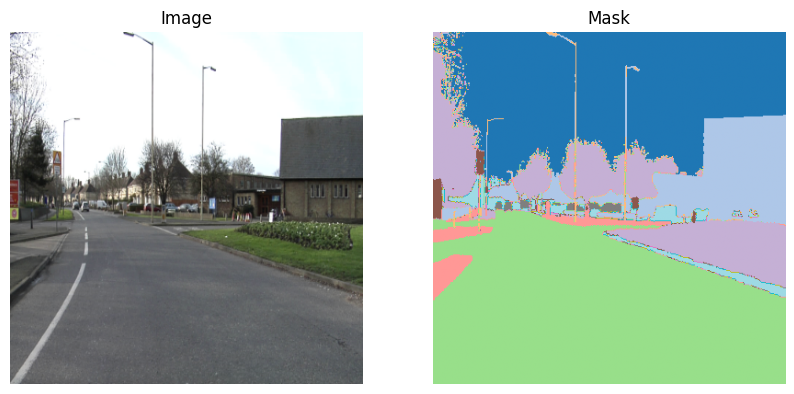

In [23]:
model.verbose = False  # Désactiver les impressions détaillées pour la suite

image, mask = valid_dataset[num]
print(f"Image shape: {image.shape}")
print(f"Mask shape: {mask.shape}")

image = image
mask = mask
print(f"Image shape after unsqueeze: {image.shape}")
print(f"Mask shape after unsqueeze: {mask.shape}")

SegDataset.show_image_and_mask(image,mask)

- Passez l'image dans le modèle en mode évaluation (`with torch.no_grad()`).
- Appliquez `torch.argmax` sur la dimension des classes pour obtenir la prédiction pixel à pixel.
- Affichez les formes des tenseurs à chaque étape pour vérification.

Model output shape: torch.Size([1, 12, 384, 384])
Model output shape after argmax: torch.Size([1, 384, 384])
Mask shape for visualization: torch.Size([384, 384])


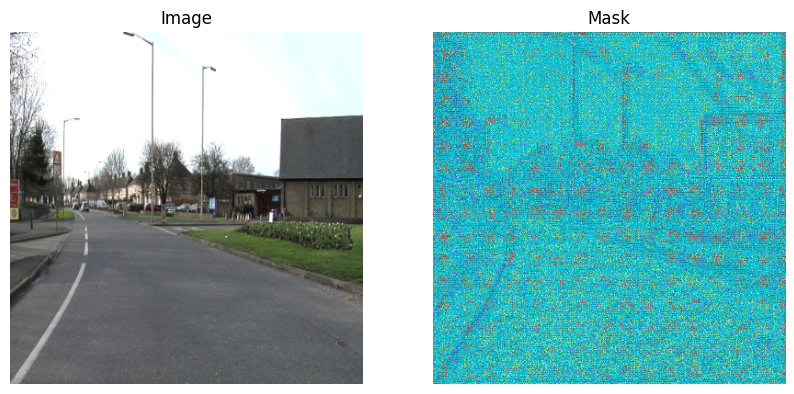

In [24]:
image = image.to(device)
with torch.no_grad():
    preds = model(image.unsqueeze(0))
    print(f"Model output shape: {preds.shape}")

# Conversion des logits en masques de classes
preds = torch.argmax(preds, dim=1) # dim=1 pour avoir la classe la plus probable pour chaque pixel
print(f"Model output shape after argmax: {preds.shape}")

pred_mask = preds[0].detach().cpu() # detach pour ne pas garder le lien avec le calcul du gradient et cpu pour visualiser sur le CPU
print(f"Mask shape for visualization: {pred_mask.shape}")

SegDataset.show_image_and_mask(image.cpu(),pred_mask)

### Tester la fonction de perte

Créez une fonction de perte `CrossEntropyLoss` et testez-la sur un exemple de sortie du modèle et son masque correspondant.

Vérifiez que les formes sont compatibles et que la perte peut être calculée correctement.

In [25]:
# test de la fonction de perte
loss_fn = nn.CrossEntropyLoss()
mask=mask.unsqueeze(0)
print(output.shape, mask.shape)
loss_fn(output, mask.to(device))

torch.Size([1, 12, 384, 384]) torch.Size([1, 384, 384])


tensor(2.4571, grad_fn=<NllLoss2DBackward0>)

### Implémenter les fonctions d'entraînement et d'évaluation

Créez trois fonctions pour gérer le cycle d'entraînement :

**`train_batch(model, data, loss_fn, optimizer, device)`** : entraîne le modèle sur un batch
- Active le mode entraînement avec `model.train()`
- Déplace les données sur le device
- Effectue la passe forward, calcule la perte et l'exactitude (accuracy)
- Effectue la rétropropagation et met à jour les poids
- Retourne la perte et l'exactitude du batch

**`validate_epoch(model, dataloader, loss_fn, device)`** : évalue le modèle sur un ensemble complet
- Active le mode évaluation avec `model.eval()` et désactive les gradients avec `@torch.no_grad()`
- Parcourt tous les batchs du dataloader avec une barre de progression (tqdm)
- Calcule la perte et l'exactitude moyennes sur l'ensemble
- Retourne la perte et l'exactitude moyennes

**`show_validation_prediction(model, dataset, num, device)`** : visualise une prédiction
- Met le modèle en mode évaluation
- Charge un exemple, effectue la prédiction et affiche l'image avec le masque prédit

In [26]:
def train_batch(model, data, loss_fn, optimizer, device):
    """
    Entraîne un batch sur le modèle donné.

    Paramètres
    ----------
    model : nn.Module
        Le modèle à entraîner.
    data : tuple
        Tuple contenant les images et les masques (tensors).
    loss_fn : callable
        Fonction de perte (ex: nn.CrossEntropyLoss).
    optimizer : torch.optim.Optimizer
        Optimiseur pour la mise à jour des poids.
    device : torch.device
        Device sur lequel exécuter le calcul.

    Retourne
    --------
    loss : float
        Valeur de la perte pour ce batch.
    acc : float
        Exactitude (accuracy) du batch.
    """
    model.train()
    data = [d.to(device) for d in data]
    images, masks = data
    preds = model(images)
    optimizer.zero_grad()
    loss = loss_fn(preds, masks)
    acc = (torch.max(preds, 1)[1] == masks).float().mean()
    loss.backward()
    optimizer.step()
    return loss.item(), acc.item()

@torch.no_grad()
def validate_epoch(model, dataloader, loss_fn, device):
    """
    Evalue le modèle sur un ensemble complet (validation/test).

    Paramètres
    ----------
    model : nn.Module
        Le modèle à évaluer.
    dataloader : DataLoader
        DataLoader fournissant les batches de données.
    loss_fn : callable
        Fonction de perte (ex: nn.CrossEntropyLoss).
    device : torch.device
        Device sur lequel exécuter le calcul.

    Retourne
    --------
    avg_loss : float
        Perte moyenne sur l'ensemble.
    avg_acc : float
        Exactitude moyenne sur l'ensemble.
    """
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0
    with tqdm(dataloader, desc="Validating", unit="batch") as t:
        for data in t:
            images, masks = [d.to(device) for d in data]
            preds = model(images)
            loss = loss_fn(preds, masks)
            acc = (torch.max(preds, 1)[1] == masks).float().mean()
            total_loss += loss.item()
            total_acc += acc.item()
            n_batches += 1
            t.set_postfix(loss=loss.item(), acc=acc.item())
    avg_loss = total_loss / n_batches
    avg_acc = total_acc / n_batches
    return avg_loss, avg_acc

@torch.no_grad()
def show_validation_prediction(model, dataset, num, device):
    """
    Affiche la prédiction de segmentation d'un exemple du dataset.

    Paramètres
    ----------
    model : nn.Module
        Le modèle de segmentation à utiliser.
    dataset : torch.utils.data.Dataset
        Le dataset contenant les images et masques.
    num : int
        L'indice de l'exemple à visualiser.
    device : torch.device
        Le device sur lequel exécuter le modèle.

    Cette fonction affiche côte à côte l'image d'entrée et le masque prédit.
    """
    model.eval()
    img, _ = dataset[num]
    img = img.unsqueeze(0).to(device)
    pred = model(img)
    pred_mask = torch.argmax(pred, dim=1)[0].cpu()
    SegDataset.show_image_and_mask(img.squeeze().cpu(), pred_mask, figsize=(8,4))

### Configurer la fonction de perte et l'optimiseur

Instanciez un optimiseur Adam avec un learning rate de 1e-3 pour entraîner tous les paramètres du modèle.

In [27]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)

### Entraîner le modèle avec early stopping

Implémentez la boucle d'entraînement complète avec les fonctionnalités suivantes :

- Définissez le nombre maximum d'époques (par exemple 100) et la patience pour l'early stopping (par exemple 10 époques sans amélioration)
- Pour chaque époque :
  - Entraînez sur tous les batchs de `train_loader` avec une barre de progression (tqdm)
  - Calculez et stockez la perte et l'exactitude moyennes d'entraînement
  - Validez sur `valid_loader` avec la fonction `validate_epoch`
  - Affichez une prédiction de validation tous les 10 époques pour suivre visuellement les progrès
  - Sauvegardez le modèle si la perte de validation s'améliore (fichier temporaire `best.pth`)
  - Incrémentez un compteur si la perte de validation ne s'améliore pas
  - Arrêtez l'entraînement et rechargez le meilleur modèle si la patience est dépassée
- Stockez toutes les métriques dans des listes pour visualisation ultérieure (`train_losses`, `train_accuracies`, `val_losses`, `val_accuracies`)
- Affichez une prédiction finale après entraînement


In [ ]:
n_epochs = 100
patience = 10  # nombre d'époques sans amélioration avant arrêt
best_val_loss = float('inf')
epochs_no_improve = 0

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(n_epochs):
    print(f"Epoch {epoch+1}/{n_epochs}")
    model.train()
    model.to(device)
    epoch_loss = 0
    epoch_acc = 0
    with tqdm(train_loader, desc=f"Epoch {epoch+1}", unit="batch") as t:
        for data in t:
            batch_loss, batch_acc = train_batch(model, data, loss_fn, optimizer, device)
            epoch_loss += batch_loss
            epoch_acc += batch_acc
            t.set_postfix(loss=batch_loss, acc=batch_acc)
    avg_loss = epoch_loss / len(train_loader)
    avg_acc = epoch_acc / len(train_loader)
    train_losses.append(avg_loss)
    train_accuracies.append(avg_acc)
    print(f"Train loss: {avg_loss:.4f}, Train acc: {avg_acc:.4f}")

    val_loss, val_acc = validate_epoch(model, valid_loader, loss_fn, device)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    print(f"Validation loss: {val_loss:.4f}, Validation acc: {val_acc:.4f}")

    # show prediction on a validation image every 10 epochs
    if (epoch) % 10 == 0:
        show_validation_prediction(model, valid_dataset, num, device)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best.pth")
        print(f"Validation loss improved. Model saved to best.pth (epoch {best_epoch}, val_loss={best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        print(f"No improvement in validation loss for {epochs_no_improve} epoch(s).")
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}. Loading best model from best.pth (epoch {best_epoch}, val_loss={best_val_loss:.4f})")
            model.load_state_dict(torch.load("best.pth", map_location=device, weights_only=True))
            os.remove("best.pth")
            break

    print("-" * 30)

show_validation_prediction(model, valid_dataset, num, device)

### Visualiser les courbes d'apprentissage

Tracez l'évolution de la perte (loss) et de l'exactitude (accuracy) pour les ensembles d'entraînement et de validation au fil des époques.

Cela permet de diagnostiquer le comportement de l'apprentissage et de détecter d'éventuels surapprentissages ou sous-apprentissages.

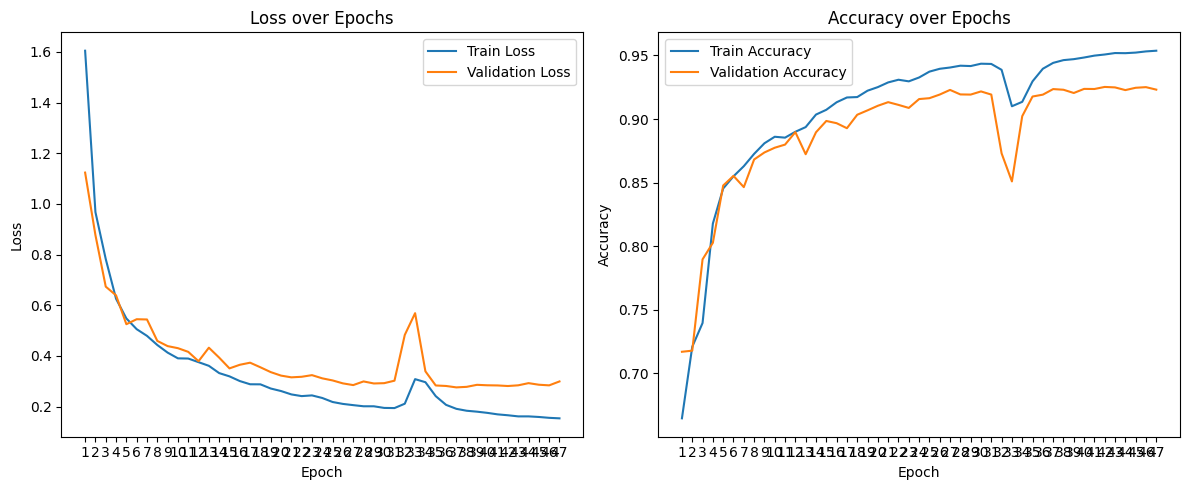

In [ ]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.xticks(range(1, len(train_losses)+1, 1))
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.xticks(range(1, len(train_accuracies)+1, 1))
plt.legend()

plt.tight_layout()
plt.show()

### Définir le chemin de sauvegarde du modèle

Construisez le chemin complet pour sauvegarder les poids du modèle en combinant le répertoire de destination (`../model_weights/`) et le nom de fichier (`14_custom_unet.pth`).

In [28]:
model_weighths_dir = "/content/drive/MyDrive/computer_vision/td14/" # mettez le votre
model_name = "14_custom_unet.pth"
weights_path = os.path.join(model_weighths_dir, model_name)

### Sauvegarder les poids du modèle entraîné

Utilisez `torch.save(model.state_dict(), weights_path)` pour sauvegarder les poids du modèle entraîné.

Cette ligne est commentée pour éviter d'écraser des poids existants lors des tests. Décommentez-la lorsque vous souhaitez effectivement sauvegarder votre modèle.

In [ ]:
# torch.save(model.state_dict(), weights_path) # commenté pour éviter d'écraser les poids déjà enregistrés
print(f"Model weights saved to {weights_path}")

Model weights saved to ../model_weights/14_custom_unet.pth


### Recharger un modèle sauvegardé

Utilisez `model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))` pour recharger les poids d'un modèle précédemment entraîné. Le paramètre `map_location` garantit que le modèle est chargé sur le bon device. Cette ligne est commentée car le modèle vient d'être entraîné.

In [29]:
model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
print(f"Model weights loaded from {weights_path}")

Model weights loaded from /content/drive/MyDrive/computer_vision/td14/14_custom_unet.pth


### Évaluer le modèle sur l'ensemble de test

Utilisez la fonction `validate_epoch` pour calculer les performances finales du modèle sur l'ensemble de test.

Affichez l'exactitude et la perte de test pour évaluer la capacité de généralisation du modèle sur des données non vues pendant l'entraînement.

In [30]:
test_loss, test_acc = validate_epoch(model,test_loader,loss_fn,device)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

Validating:   0%|          | 0/4 [00:00<?, ?batch/s]

Test Accuracy: 0.9149, Test Loss: 0.3188


### Visualiser une prédiction sur l'ensemble de test

Mettez le modèle en mode évaluation, chargez un exemple de l'ensemble de test, effectuez une prédiction sans calcul de gradient, et visualisez le résultat avec `show_image_and_mask`.

Cette visualisation qualitative permet d'apprécier la qualité de la segmentation sur des données jamais vues pendant l'entraînement.

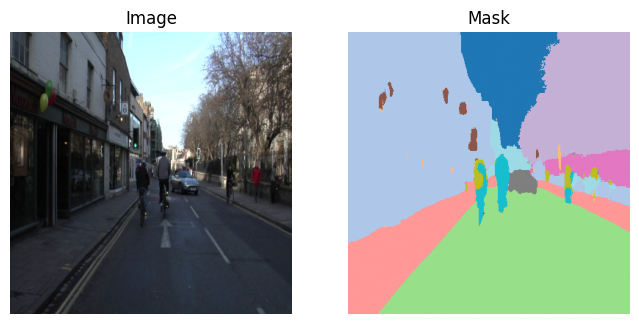

In [35]:
model.eval()
num = 100 # dans cet exercice, le jeux de test n'est pas très diversifié....
with torch.no_grad():
    img, true_mask = test_dataset[num]
    img = img.unsqueeze(0).to(device)
    pred = model(img)
    pred_mask = torch.argmax(pred, dim=1)[0].cpu()
    SegDataset.show_image_and_mask(img.squeeze().cpu(), pred_mask, figsize=(8,4))